In [1]:
from pathlib import Path

ROOT = Path.cwd().resolve().parent

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f"{ROOT}/data/raw/customer_booking.csv", encoding = 'latin1')
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [4]:
df['booking_complete'].value_counts(normalize = True)

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64

In [5]:
df['booking_origin'].value_counts()

booking_origin
Australia               17872
Malaysia                 7174
South Korea              4559
Japan                    3885
China                    3387
                        ...  
Ghana                       1
Gibraltar                   1
Guatemala                   1
Algeria                     1
Svalbard & Jan Mayen        1
Name: count, Length: 104, dtype: int64

In [6]:
counts = df['booking_origin'].value_counts()

top_k_samples = counts[counts>80]

print(f"Percentage of data covered by top {len(top_k_samples)}: {top_k_samples.values.sum()}")

Percentage of data covered by top 20: 49006


In [7]:
percentage_of_data_covered = []

for value in top_k_samples.values:
    percentage = round(value/len(df),4)*100
    percentage_of_data_covered.append(percentage)

df_booking_origin_eda = pd.DataFrame(data=[top_k_samples.index, percentage_of_data_covered]).T
df_booking_origin_eda.columns = ['Country', 'Percentage']
df_booking_origin_eda

,Country,Percentage
0,Australia,35.74
1,Malaysia,14.35
2,South Korea,9.12
3,Japan,7.77
4,China,6.77
5,Indonesia,4.74
6,Taiwan,4.15
7,Thailand,4.06
8,India,2.54
9,New Zealand,2.15


In [8]:
del df_booking_origin_eda

In [9]:
masked = [x for x in df.select_dtypes(include='number').columns if df[x].nunique()>2]

df[masked].describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_duration
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,7.277561
std,1.020165,90.451378,33.88767,5.41266,1.496863
min,1.000000,0.000000,0.00000,0.00000,4.670000
25%,1.000000,21.000000,5.00000,5.00000,5.620000
50%,1.000000,51.000000,17.00000,9.00000,7.570000
75%,2.000000,115.000000,28.00000,13.00000,8.830000
max,9.000000,867.000000,778.00000,23.00000,9.500000


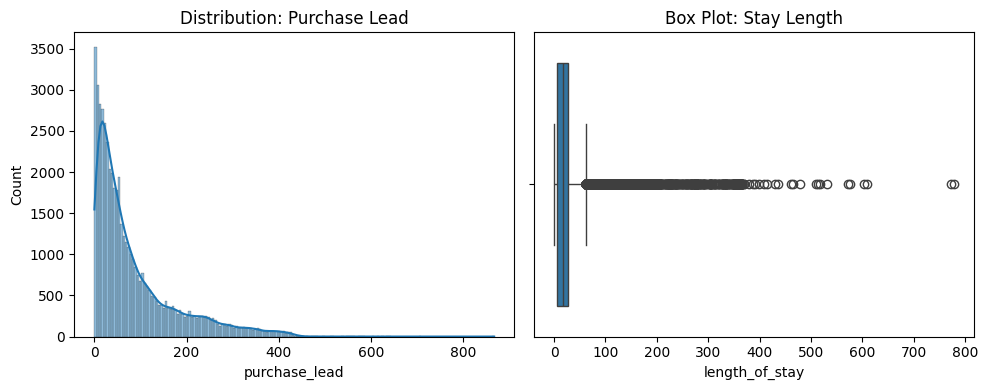

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(data = df, x = 'purchase_lead', kde=True, ax = ax[0])
ax[0].set_title('Distribution: Purchase Lead')

sns.boxplot(df['length_of_stay'], orient = 'h', ax = ax[1])
ax[1].set_title('Box Plot: Stay Length')

plt.tight_layout()
plt.show()

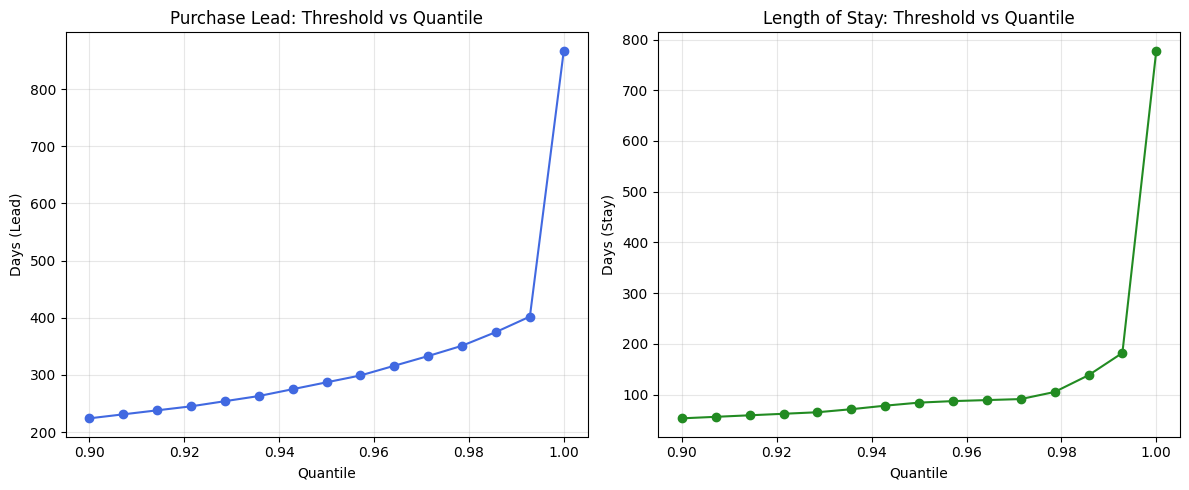

In [11]:
quantiles = np.linspace(0.90, 1.0, 15)

lead_thresholds = [df['purchase_lead'].quantile(q) for q in quantiles]
stay_thresholds = [df['length_of_stay'].quantile(q) for q in quantiles]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(quantiles, lead_thresholds, marker='o', color='royalblue')
plt.title("Purchase Lead: Threshold vs Quantile")
plt.xlabel('Quantile')
plt.ylabel('Days (Lead)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(quantiles, stay_thresholds, marker='o', color='forestgreen')
plt.title("Length of Stay: Threshold vs Quantile")
plt.xlabel('Quantile')
plt.ylabel('Days (Stay)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
length_of_stay_threshold = df['length_of_stay'].quantile(0.98)
print('Feature: Length of Stay\n')
print(length_of_stay_threshold)

normal_stay_data = df[df['length_of_stay']<=length_of_stay_threshold]
outliers = df[df['length_of_stay']>length_of_stay_threshold]

print("Class Distribution in Normal length of stay data:")
print(f"{normal_stay_data['booking_complete'].value_counts(normalize=True)*100}")

print("Class Distribution in Outliers:")
print(f"{outliers['booking_complete'].value_counts(normalize=True)*100}")

Feature: Length of Stay

110.0
Class Distribution in Normal length of stay data:
booking_complete
0    84.990206
1    15.009794
Name: proportion, dtype: float64
Class Distribution in Outliers:
booking_complete
0    87.701613
1    12.298387
Name: proportion, dtype: float64


In [13]:
purchase_lead_threshold = df['purchase_lead'].quantile(0.98)
print('Feature: Purchase Lead\n')
print(purchase_lead_threshold)

normal_lead_data = df[df['purchase_lead']<=purchase_lead_threshold]
outliers = df[df['purchase_lead']>purchase_lead_threshold]

print("Class Distribution in Normal purchase lead data:")
print(f"{normal_lead_data['booking_complete'].value_counts(normalize=True)*100}")

print("Class Distribution in Outliers:")
print(f"{outliers['booking_complete'].value_counts(normalize=True)*100}")

Feature: Purchase Lead

355.0
Class Distribution in Normal purchase lead data:
booking_complete
0    85.02244
1    14.97756
Name: proportion, dtype: float64
Class Distribution in Outliers:
booking_complete
0    86.122449
1    13.877551
Name: proportion, dtype: float64


In [14]:
def rows_removed(quantiles, df):
    number_of_rows_removed = []
    for lead_threshold, stay_threshold in zip(lead_thresholds, stay_thresholds):
        df_cleaned = df[
        (df['purchase_lead']<=lead_threshold) & (df['length_of_stay']<=stay_threshold)
        ]

        number_of_rows_removed.append(len(df)-len(df_cleaned))
    return number_of_rows_removed

Features: Purchase Lead and Length of Stay


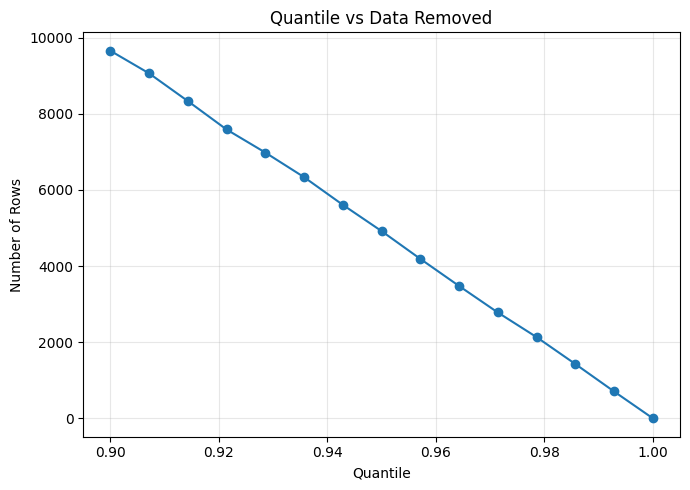

In [15]:
number_of_rows_removed = rows_removed(quantiles, df)

print("Features: Purchase Lead and Length of Stay")

plt.figure(figsize=(7,5))

plt.plot(quantiles, number_of_rows_removed, marker='o')
plt.title('Quantile vs Data Removed')
plt.xlabel('Quantile')
plt.ylabel('Number of Rows')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
def routes_vs_data_captured(thresholds, route_ct):
    
    routes, data_captured = [], []
    for value in thresholds:
        temp = route_ct.query(f'Class_1 > {value}')
        data_captured.append(temp['Class_1'].sum()/df['booking_complete'].value_counts()[1])
        routes.append(len(temp))

    return routes, data_captured

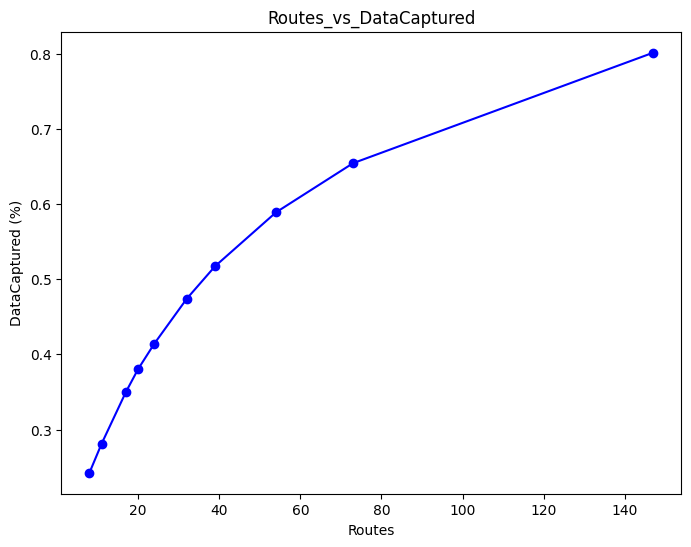

In [17]:
route_ct = pd.crosstab(df['route'], df['booking_complete'])
route_ct.columns = ['Class_0', 'Class_1']

thresholds = list(range(10, 101, 10))

routes, data_captured = routes_vs_data_captured(thresholds, route_ct)

plt.figure(figsize=(8,6))
plt.plot(routes, data_captured, marker='o', color='blue')
plt.title('Routes_vs_DataCaptured')
plt.xlabel('Routes')
plt.ylabel('DataCaptured (%)')
plt.show()